In [5]:
#A1
df1 = pd.read_excel(FILE, sheet_name="Purchase data").iloc[:, :5]
X = df1[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values.astype(float)
y = df1['Payment (Rs)'].values.astype(int).reshape(-1, 1)
rank = np.linalg.matrix_rank(X)
print("Rank of feature matrix X:", rank)
cost_per_unit = np.linalg.pinv(X) @ y
print("Cost per Candy, Mango(kg), Milk Packet:", cost_per_unit.ravel())

Rank of feature matrix X: 3
Cost per Candy, Mango(kg), Milk Packet: [ 1. 55. 18.]


In [8]:
#A2
from sklearn.neighbors import KNeighborsClassifier
df1['Class'] = np.where(df1['Payment (Rs)'] > 200, 'RICH', 'POOR')
X = df1[['Candies (#)', 'Mangoes (Kg)', 'Milk Packets (#)']].values
y = df1['Class'].values
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X, y)
pred = model.predict(X)
print(df1[['Customer','Payment (Rs)','Class']])
print("Predictions:", pred)
print("Training accuracy:", (pred == y).mean())

  Customer  Payment (Rs) Class
0      C_1           386  RICH
1      C_2           289  RICH
2      C_3           393  RICH
3      C_4           110  POOR
4      C_5           280  RICH
5      C_6           167  POOR
6      C_7           271  RICH
7      C_8           274  RICH
8      C_9           148  POOR
9     C_10           198  POOR
Predictions: ['RICH' 'RICH' 'RICH' 'POOR' 'RICH' 'POOR' 'RICH' 'RICH' 'POOR' 'RICH']
Training accuracy: 0.9


numpy mean: 1560.6634538152612 | numpy var: 58496.49239931613
custom mean: 1560.6634538152598 | custom var: 58496.49239931618
avg numpy time (s): 5.437399995571468e-05
avg custom time (s): 0.0001463864000470494
Wednesday sample mean: 1550.7060000000001 | Population mean: 1560.6634538152612
April sample mean: 1698.9526315789474 | Population mean: 1560.6634538152612
P(loss): 0.4979919678714859
P(profit): 0.4979919678714859
P(profit | Wednesday): 0.42


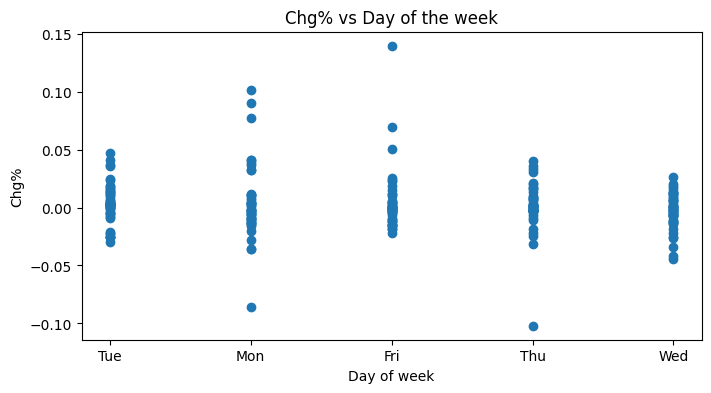

In [9]:
#A3
import time
df3 = pd.read_excel(FILE, sheet_name="IRCTC Stock Price")
price = df3['Price'].values.astype(float)
np_mean, np_var = np.mean(price), np.var(price)
print("numpy mean:", np_mean, "| numpy var:", np_var)
def my_mean(x):
    total = 0.0
    for v in x:
        total += v
    return total / len(x)
def my_var(x):
    m = my_mean(x)
    total = 0.0
    for v in x:
        total += (v - m) ** 2
    return total / len(x)
custom_mean, custom_var = my_mean(price), my_var(price)
print("custom mean:", custom_mean, "| custom var:", custom_var)
t0 = time.perf_counter()
for _ in range(10):
    np.mean(price); np.var(price)
numpy_time = (time.perf_counter() - t0) / 10
t0 = time.perf_counter()
for _ in range(10):
    my_mean(price); my_var(price)
custom_time = (time.perf_counter() - t0) / 10
print("avg numpy time (s):", numpy_time)
print("avg custom time (s):", custom_time)
wed_prices = df3.loc[df3['Day'] == 'Wed', 'Price'].astype(float)
print("Wednesday sample mean:", wed_prices.mean(), "| Population mean:", np_mean)
apr_prices = df3.loc[df3['Month'] == 'Apr', 'Price'].astype(float)
print("April sample mean:", apr_prices.mean(), "| Population mean:", np_mean)
chg = df3['Chg%'].astype(float)
is_loss = chg.apply(lambda x: x < 0)
p_loss = is_loss.mean()
print("P(loss):", p_loss)
is_profit = chg > 0
is_wed = df3['Day'] == 'Wed'
p_profit = is_profit.mean()
p_profit_and_wed = (is_profit & is_wed).mean()
p_wed = is_wed.mean()
p_profit_given_wed = p_profit_and_wed / p_wed
print("P(profit):", p_profit)
print("P(profit | Wednesday):", p_profit_given_wed)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.scatter(df3['Day'], df3['Chg%'])
plt.xlabel("Day of week"); plt.ylabel("Chg%")
plt.title("Chg% vs Day of the week")
plt.show()

In [10]:
#A4
df4 = pd.read_excel(FILE, sheet_name="thyroid0387_UCI")
print("Shape:", df4.shape)
print(df4.dtypes)
num_cols = ['age','TSH','T3','TT4','T4U','FTI','TBG']
for c in num_cols:
    df4[c] = pd.to_numeric(df4[c], errors='coerce')   # '?' becomes NaN
print(df4[num_cols].describe().T[['min','max','mean']])
print("Missing values per numeric attribute:\n", df4[num_cols].isna().sum())
print("Missing 'sex' entries:", (df4['sex'] == '?').sum())
for c in num_cols:
    q1, q3 = df4[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((df4[c] < q1 - 1.5*iqr) | (df4[c] > q3 + 1.5*iqr)).sum()
    print(f"{c}: {outliers} outliers (range {df4[c].min()}–{df4[c].max()})")

Shape: (9172, 31)
Record ID                     int64
age                           int64
sex                          object
on thyroxine                 object
query on thyroxine           object
on antithyroid medication    object
sick                         object
pregnant                     object
thyroid surgery              object
I131 treatment               object
query hypothyroid            object
query hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH measured                 object
TSH                          object
T3 measured                  object
T3                           object
TT4 measured                 object
TT4                          object
T4U measured                 object
T4U                          object
FTI measured                 object
FTI                          object
TBG measur

In [12]:
#A5
binary_cols = ['on thyroxine','query on thyroxine','on antithyroid medication','sick',
               'pregnant','thyroid surgery','I131 treatment','query hypothyroid',
               'query hyperthyroid','lithium','goitre','tumor','hypopituitary','psych',
               'TSH measured','T3 measured','TT4 measured','T4U measured','FTI measured','TBG measured']
bin_df = df4[binary_cols].replace({'t': 1, 'f': 0})
v1 = bin_df.iloc[0].values.astype(int)
v2 = bin_df.iloc[1].values.astype(int)
f11 = np.sum((v1==1) & (v2==1))
f00 = np.sum((v1==0) & (v2==0))
f10 = np.sum((v1==1) & (v2==0))
f01 = np.sum((v1==0) & (v2==1))
JC = f11 / (f01 + f10 + f11)
SMC = (f11 + f00) / (f00 + f01 + f10 + f11)
print("JC:", JC, "| SMC:", SMC)

JC: 0.25 | SMC: 0.85


/tmp/ipykernel_629/779290329.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bin_df = df4[binary_cols].replace({'t': 1, 'f': 0})


In [14]:
#A6
d = df4.copy()
d[binary_cols] = d[binary_cols].replace({'t': 1, 'f': 0})
d['sex'] = d['sex'].replace({'F': 0, 'M': 1, '?': np.nan})
for c in num_cols:
    d[c] = pd.to_numeric(d[c], errors='coerce')
for c in ['referral source', 'Condition']:
    d[c] = pd.factorize(d[c])[0]
feat_cols = [c for c in d.columns if c != 'Record ID']
vecs = d[feat_cols].fillna(0).values.astype(float)
A, B = vecs[0], vecs[1]
cos_sim = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
print("Cosine similarity:", cos_sim)

Cosine similarity: 0.22101789810378902


/tmp/ipykernel_629/3359371784.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d[binary_cols] = d[binary_cols].replace({'t': 1, 'f': 0})
/tmp/ipykernel_629/3359371784.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d['sex'] = d['sex'].replace({'F': 0, 'M': 1, '?': np.nan})


/tmp/ipykernel_629/3331319412.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bin20 = df4[binary_cols].iloc[:n].replace({'t':1,'f':0}).values.astype(int)
/tmp/ipykernel_629/3331319412.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d20[binary_cols] = d20[binary_cols].replace({'t':1,'f':0})
/tmp/ipykernel_629/3331319412.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the

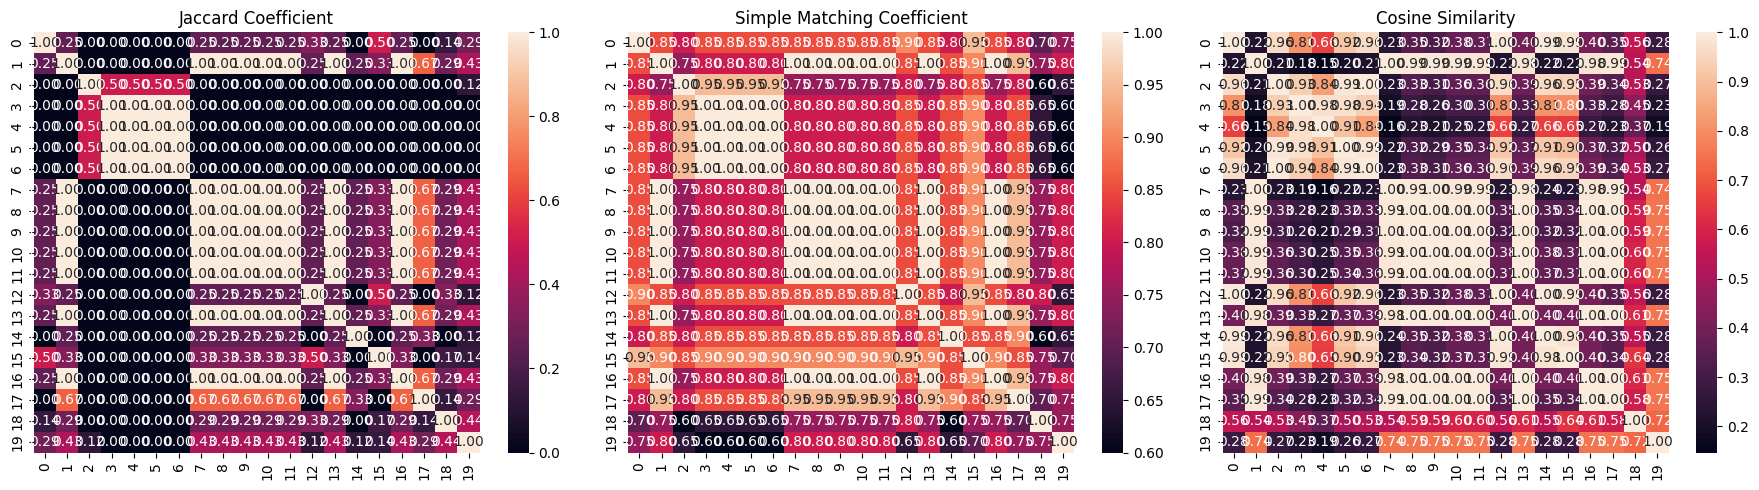

In [15]:
#A7
import seaborn as sns
import matplotlib.pyplot as plt
n = 20
bin20 = df4[binary_cols].iloc[:n].replace({'t':1,'f':0}).values.astype(int)
d20 = df4.iloc[:n].copy()
d20[binary_cols] = d20[binary_cols].replace({'t':1,'f':0})
d20['sex'] = d20['sex'].replace({'F':0,'M':1,'?':np.nan})
for c in num_cols:
    d20[c] = pd.to_numeric(d20[c], errors='coerce')
for c in ['referral source','Condition']:
    d20[c] = pd.factorize(d20[c])[0]
vecs20 = d20[[c for c in d20.columns if c != 'Record ID']].fillna(0).values.astype(float)
JC_mat, SMC_mat, COS_mat = (np.zeros((n,n)) for _ in range(3))
for i in range(n):
    for j in range(n):
        v1, v2 = bin20[i], bin20[j]
        f11 = np.sum((v1==1)&(v2==1)); f00 = np.sum((v1==0)&(v2==0))
        f10 = np.sum((v1==1)&(v2==0)); f01 = np.sum((v1==0)&(v2==1))
        JC_mat[i,j] = f11/(f01+f10+f11) if (f01+f10+f11) else 0
        SMC_mat[i,j] = (f11+f00)/(f00+f01+f10+f11)
        a, b = vecs20[i], vecs20[j]
        denom = np.linalg.norm(a) * np.linalg.norm(b)
        COS_mat[i,j] = np.dot(a,b)/denom if denom else 0
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.heatmap(JC_mat, annot=True, fmt=".2f", ax=axes[0]).set_title("Jaccard Coefficient")
sns.heatmap(SMC_mat, annot=True, fmt=".2f", ax=axes[1]).set_title("Simple Matching Coefficient")
sns.heatmap(COS_mat, annot=True, fmt=".2f", ax=axes[2]).set_title("Cosine Similarity")
plt.tight_layout()
plt.show()

In [16]:
#A8
df8 = df4.copy()
df8 = df8.replace('?', np.nan)
for c in num_cols:
    df8[c] = pd.to_numeric(df8[c], errors='coerce')
for c in num_cols:
    df8[c] = df8[c].fillna(df8[c].median())
df8['sex'] = df8['sex'].fillna(df8['sex'].mode()[0])

print(df8[num_cols + ['sex']].isna().sum())

age    0
TSH    0
T3     0
TT4    0
T4U    0
FTI    0
TBG    0
sex    0
dtype: int64


In [17]:
#A9
from sklearn.preprocessing import MinMaxScaler
df9 = df8.copy()
scaler = MinMaxScaler()
df9[num_cols] = scaler.fit_transform(df8[num_cols])
print(df9[num_cols].describe().T[['min','max']])

     min  max
age  0.0  1.0
TSH  0.0  1.0
T3   0.0  1.0
TT4  0.0  1.0
T4U  0.0  1.0
FTI  0.0  1.0
TBG  0.0  1.0
